# Fit a regular vine

This example loads six asset price series from `prices.csv`, fits a six-node vine, and reads its final conditional probabilities.

In [1]:
from helpers import ASSET_NAMES, PRICES_PATH, load_assets
from vines import Method, Vine

In [2]:
# Load asset price data
assets = load_assets()
assert len(assets) == 6
print(f"loaded {len(assets[0].prices())} prices for {', '.join(ASSET_NAMES)} from {PRICES_PATH}")

loaded 1999 prices for BTC, ETH, LINK, XRP, SOL, DOGE from /Users/shaun/Code/DEVELOPMENT/cpp-vines/prices.csv


In [3]:
# Determine best fitting R-Vine copula
marginals = [asset.u_values() for asset in assets]
vine = Vine(marginals, max_nodes=6, method=Method.CMPI)
vine.fit()
print(f"{vine}")

T1: 12, 23, 25, 16, 24
  copulas: StudentT, StudentT, StudentT, StudentT, StudentT
  params: [[0.837514, 3.74549], [0.806869, 3.11871], [0.742954, 2.78491], [0.736181, 3.8322], [0.735006, 3.30941]]
  tau: [0.636292, 0.601024, 0.53571, 0.535265, 0.532138]
T2: 34|2, 26|1, 14|2, 35|2
  copulas: Clayton, StudentT, Clayton, StudentT
  params: [[0.691483], [0.346194, 5.22943], [0.500123], [0.309249, 5.35241]]
  tau: [0.251513, 0.230771, 0.212243, 0.211329]
T3: 46|12, 45|23, 13|24
  copulas: StudentT, StudentT, StudentT
  params: [[0.279763, 7.54972], [0.160353, 7.1231], [0.113428, 9.22387]]
  tau: [0.20596, 0.113593, 0.0819848]
T4: 36|124, 15|234
  copulas: StudentT, StudentT
  params: [[0.176514, 10.7521], [0.196868, 6.83139]]
  tau: [0.138312, 0.132616]
T5: 56|1234
  copulas: Clayton
  params: [[0.19827]]
  tau: [0.106285]


In [4]:
# Print the latest results
results = vine.final_results()
print(f"latest left given right: {results.left_given_right[-1]:.2f}")
print(f"latest right given left: {results.right_given_left[-1]:.2f}")

latest left given right: -38.20
latest right given left: -20.92


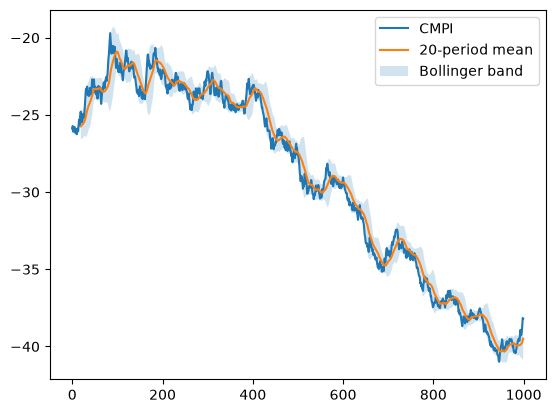

In [5]:
from statistics import fmean, stdev

import matplotlib.pyplot as plt

cmpi = results.left_given_right[-1000:]
windows = [cmpi[i:i + 20] for i in range(len(cmpi) - 19)]
middle = [fmean(window) for window in windows]
width = [2 * stdev(window) for window in windows]
x = range(19, len(cmpi))

plt.plot(cmpi, label="CMPI")
plt.plot(x, middle, label="20-period mean")
plt.fill_between(x, [m - w for m, w in zip(middle, width)], [m + w for m, w in zip(middle, width)], alpha=0.2, label="Bollinger band")
plt.legend()
plt.show()